In [1]:
import pandas as pd
import numpy as np
import pickle
import tabulate
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score, classification_report
from sklearn.cluster import KMeans

In [2]:
"""
Import the “Human activity semi-supervised.csv” dataset. Remove "subject" from the 
features as it is a number assigned to a person. Also, drop all the rows without labels
"""

# Load and clean training data
data = pd.read_csv("Human activity semi-supervised.csv")
data = data.drop(columns=["subject"])  # Drop 'subject' column explicitly
data.isnull().sum()


C:\Users\dangs\AppData\Local\Temp\ipykernel_20368\2833879851.py:7: DtypeWarning: Columns (562) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("Human activity semi-supervised.csv")


tBodyAcc-mean()-X                          0
tBodyAcc-mean()-Y                          0
tBodyAcc-mean()-Z                          0
tBodyAcc-std()-X                           0
tBodyAcc-std()-Y                           0
                                        ... 
angle(tBodyGyroJerkMean,gravityMean)       0
angle(X,gravityMean)                       0
angle(Y,gravityMean)                       0
angle(Z,gravityMean)                       0
Activity                                7346
Length: 562, dtype: int64

In [3]:
# Drop rows with missing labels
data = data.dropna()  # Remove rows with missing labels
data.head(n=10)

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity
10,0.276880,-0.012722,-0.103438,-0.994815,-0.973077,-0.985357,-0.995509,-0.973948,-0.985172,-0.940028,...,0.348771,0.057682,0.080699,0.595791,-0.475802,0.115931,-0.851562,0.187609,-0.034681,STANDING
38,0.237154,0.007825,-0.122838,-0.979954,-0.866193,-0.968290,-0.980179,-0.882316,-0.966097,-0.939637,...,-0.444482,-0.816502,0.321250,-0.050328,0.584280,-0.426198,-0.654356,0.006141,-0.212753,SITTING
60,0.276729,-0.017210,-0.105638,-0.994788,-0.991031,-0.993187,-0.995890,-0.990625,-0.992795,-0.933459,...,-0.860312,-0.979142,-0.328275,0.447151,0.079284,-0.108642,0.397134,-0.544680,-0.432871,LAYING
89,0.306996,-0.013787,-0.180162,-0.239030,0.072865,-0.247204,-0.282546,0.008008,-0.261674,-0.091285,...,-0.037653,-0.268873,-0.158136,-0.759189,-0.270995,0.201839,-0.764601,0.259326,0.040397,WALKING
125,0.358455,0.017975,-0.084159,-0.171988,-0.188332,-0.399555,-0.218408,-0.246541,-0.363535,0.244225,...,-0.299425,-0.691170,-0.294788,-0.582192,0.046131,-0.112673,-0.768340,0.256712,0.040474,WALKING_DOWNSTAIRS
155,0.158517,0.004256,-0.018779,-0.406022,-0.083614,-0.012498,-0.466763,-0.101567,0.094817,-0.232947,...,-0.522033,-0.821995,0.498854,0.179758,-0.818937,-0.056916,-0.698389,0.304878,0.044325,WALKING_UPSTAIRS


In [4]:
"""
Train a  random forest classifier on “Human activity semi-supervised.csv” dataset with a 
number of estimators= 10 and maximum depth= 10.

Evaluate the performance of the model on the “test.csv” data set by providing the 
confusion matrix and metrics of classification (accuracy, sensitivity, specificity, and f1 
score)
"""

# Separate features and target
target = data.iloc[:, -1]
features = data.iloc[:, :-1]

# Standardize the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Encode target labels
label_encoder = LabelEncoder()
target_encoded = label_encoder.fit_transform(target)

# Load and clean test data
test_data = pd.read_csv("test.csv")
test_data = test_data.drop(columns=["subject"])  # Drop 'subject' column explicitly
target_test = test_data.iloc[:, -1]
features_test = test_data.iloc[:, :-1]

# Standardize test features using the same scaler
features_test_scaled = scaler.transform(features_test)
target_test_encoded = label_encoder.transform(target_test)


In [5]:
def train_forest(estimators, depth, X_train, y_train, X_test, y_test, class_labels, n_clusters):
    rf_model = RandomForestClassifier(n_estimators=estimators, max_depth=depth, random_state=42, class_weight='balanced')
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    
    # Compute metrics
    conf_matrix = confusion_matrix(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    sensitivity = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    # Specificity calculation
    specificity_list = []
    for i in range(len(conf_matrix)):
        tn = conf_matrix.sum() - (conf_matrix[i, :].sum() + conf_matrix[:, i].sum() - conf_matrix[i, i])
        fp = conf_matrix[:, i].sum() - conf_matrix[i, i]
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificity_list.append(specificity)
    specificity = np.mean(specificity_list)
    
    print(f"Accuracy: {accuracy:.4f}\nSensitivity: {sensitivity:.4f}\nSpecificity: {specificity:.4f}\nF1 Score: {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Random Forest (n={estimators}, depth={depth}, n_cluster={n_clusters}) - Confusion Matrix")
    plt.show()
    
    return rf_model, accuracy, sensitivity, specificity, f1

Accuracy: 0.3828
Sensitivity: 0.3853
Specificity: 0.8770
F1 Score: 0.3591

Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.53      0.54       537
           1       0.28      0.23      0.25       491
           2       0.39      0.51      0.44       532
           3       0.27      0.08      0.12       496
           4       0.31      0.66      0.42       420
           5       0.53      0.30      0.38       471

    accuracy                           0.38      2947
   macro avg       0.39      0.39      0.36      2947
weighted avg       0.39      0.38      0.36      2947



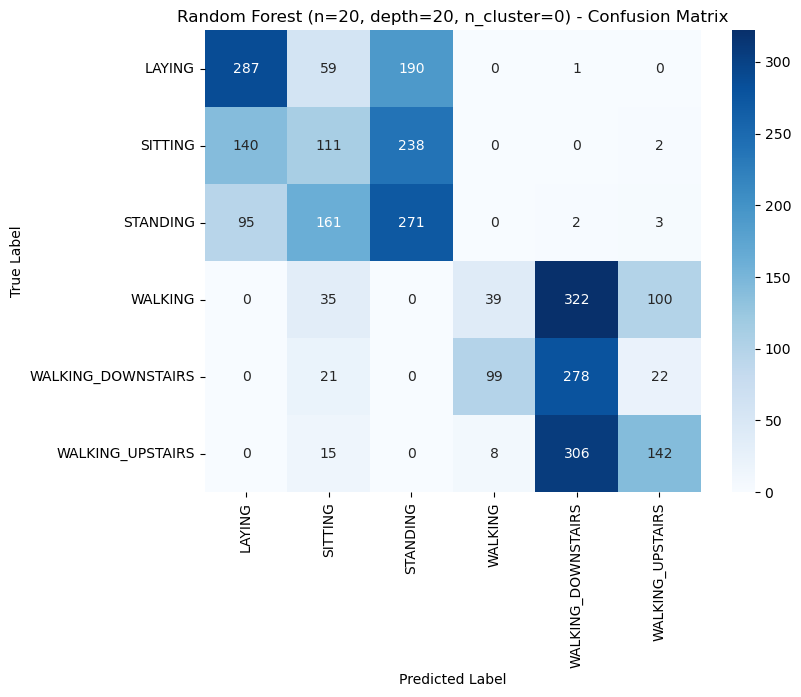

(RandomForestClassifier(class_weight='balanced', max_depth=20, n_estimators=20,
                        random_state=42),
 0.3827621309806583,
 0.3853230646972887,
 0.8770212247356195,
 0.35909203720944655)

In [6]:
# Train RFC on the data
train_forest(
        estimators=20, depth=20,
        X_train=features_scaled, y_train=target_encoded,
        X_test=features_test_scaled, y_test=target_test_encoded,
        class_labels=label_encoder.classes_, n_clusters=0
    )


``` python
import numpy as np 
import pandas as pd 
from pathlib import Path 
from numpy import linalg 
from sklearn.cluster import KMeans

Data_unlabeled = pd.read_csv(Path("/content/Human activity semi supervised.csv")) 
Data_unlabeled2= Data_unlabeled.dropna() 
Data_labeled=Data_unlabeled.copy() 
Data_train= Data_unlabeled.drop(["subject","Activity"], axis=1)

n_clusters=9 
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto").fit(Data_train) 
kmeans_2=kmeans.labels_  
centers = kmeans.cluster_centers_

Features= Data_unlabeled2.drop(["subject","Activity"], axis=1) 
Feature=Features.to_numpy()

num_rows, num_cols = Feature.shape
dist=[None]*num_rows 
for i in range(0,n_clusters): 
    for j in range(0,len(num_cols)): 
        dist[j] = np.linalg.norm(centers[i]-Feature[j]) 
    index_min = np.argmin(dist) 
    for k in range(0,len(kmeans_2)): 
        if kmeans_2[k]==i: 
            Data_labeled.loc[k,"Activity"]=Data_unlabeled.loc[Features.index[index_min],"Activity"] 
```

d:\MiniMiniConda\envs\MSE413\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Accuracy: 0.3655
Sensitivity: 0.3599
Specificity: 0.8729
F1 Score: 0.3513

Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.75      0.58       537
           1       0.16      0.23      0.18       491
           2       0.46      0.27      0.34       532
           3       0.30      0.15      0.20       496
           4       0.32      0.29      0.30       420
           5       0.54      0.46      0.50       471

    accuracy                           0.37      2947
   macro avg       0.37      0.36      0.35      2947
weighted avg       0.38      0.37      0.35      2947



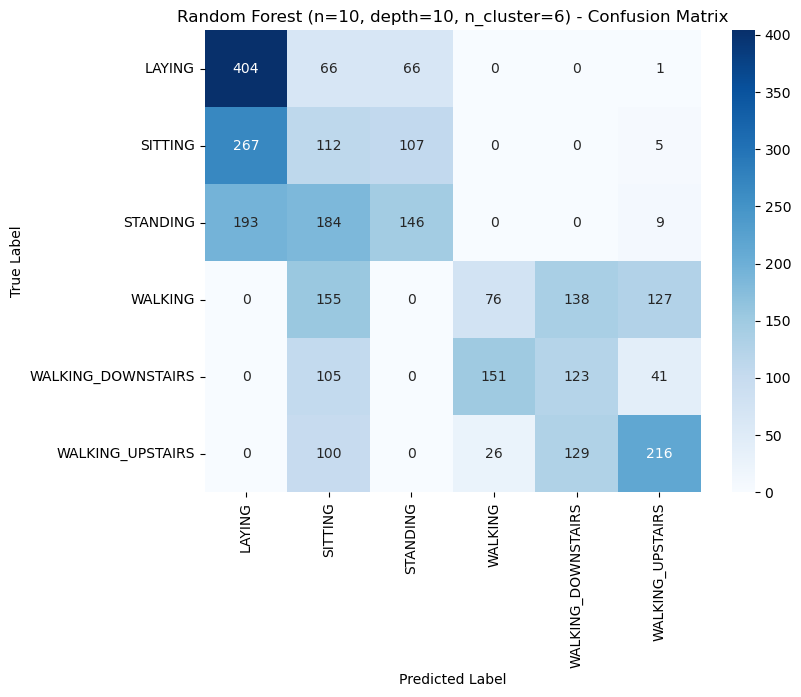

In [7]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init="auto")
kmeans_labels = kmeans.fit_predict(features_scaled)

# Assign cluster labels based on majority voting
labeled_data = pd.DataFrame(features_scaled, columns=[f'feature_{i}' for i in range(features_scaled.shape[1])])
labeled_data["cluster"] = kmeans_labels
labeled_data["true_label"] = target.values
cluster_to_label = labeled_data.groupby("cluster")["true_label"].agg(lambda x: x.value_counts().idxmax()).to_dict()
predicted_labels = np.array([cluster_to_label[c] for c in kmeans_labels])
predicted_labels_encoded = label_encoder.transform(predicted_labels)

# Train Random Forest on labeled data
rf_model, accuracy, sensitivity, specificity, f1 = train_forest(
    estimators=10, depth=10,
    X_train=features_scaled, y_train=predicted_labels_encoded,
    X_test=features_test_scaled, y_test=target_test_encoded,
    class_labels=label_encoder.classes_, n_clusters=6
)

In [8]:
def semi_supervised_auto_labeling(n_clusters, features_scaled, target, features_test_scaled, target_test_encoded, label_encoder):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
    kmeans_labels = kmeans.fit_predict(features_scaled)
    
    # Assign cluster labels based on majority voting
    labeled_data = pd.DataFrame(features_scaled, columns=[f'feature_{i}' for i in range(features_scaled.shape[1])])
    labeled_data["cluster"] = kmeans_labels
    labeled_data["true_label"] = target.values
    cluster_to_label = labeled_data.groupby("cluster")["true_label"].agg(lambda x: x.value_counts().idxmax()).to_dict()
    predicted_labels = np.array([cluster_to_label[c] for c in kmeans_labels])
    predicted_labels_encoded = label_encoder.transform(predicted_labels)
    
    # Train Random Forest on labeled data
    rf_model, accuracy, sensitivity, specificity, f1 = train_forest(
        estimators=10, depth=10,
        X_train=features_scaled, y_train=predicted_labels_encoded,
        X_test=features_test_scaled, y_test=target_test_encoded,
        class_labels=label_encoder.classes_, n_clusters=n_clusters
    )
    with open(f"rf__E10_D10_model_{n_clusters}_clusters.pkl", "wb") as file:
        pickle.dump(rf_model, file)
    
    return rf_model, accuracy, sensitivity, specificity, f1

d:\MiniMiniConda\envs\MSE413\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\MiniMiniConda\envs\MSE413\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\MiniMiniConda\envs\MSE413\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\MiniMiniConda\envs\MSE413\lib\site-packages\sklearn\metrics\_classi

Accuracy: 0.4293
Sensitivity: 0.4064
Specificity: 0.8848
F1 Score: 0.2829

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.60      0.58       537
           1       0.00      0.00      0.00       491
           2       0.45      0.86      0.59       532
           3       0.35      0.98      0.52       496
           4       0.00      0.00      0.00       420
           5       0.00      0.00      0.00       471

    accuracy                           0.43      2947
   macro avg       0.23      0.41      0.28      2947
weighted avg       0.25      0.43      0.30      2947



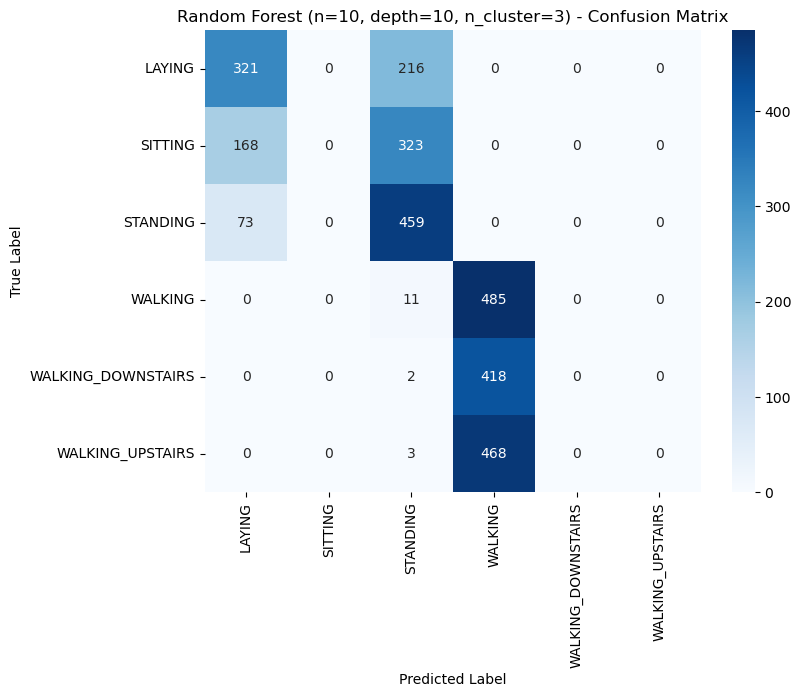

d:\MiniMiniConda\envs\MSE413\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\MiniMiniConda\envs\MSE413\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\MiniMiniConda\envs\MSE413\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\MiniMiniConda\envs\MSE413\lib\site-packages\sklearn\metrics\_classi

Accuracy: 0.4907
Sensitivity: 0.4728
Specificity: 0.8973
F1 Score: 0.3882

Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.69      0.62       537
           1       0.00      0.00      0.00       491
           2       0.46      0.81      0.58       532
           3       0.41      0.60      0.48       496
           4       0.00      0.00      0.00       420
           5       0.57      0.74      0.64       471

    accuracy                           0.49      2947
   macro avg       0.33      0.47      0.39      2947
weighted avg       0.34      0.49      0.40      2947



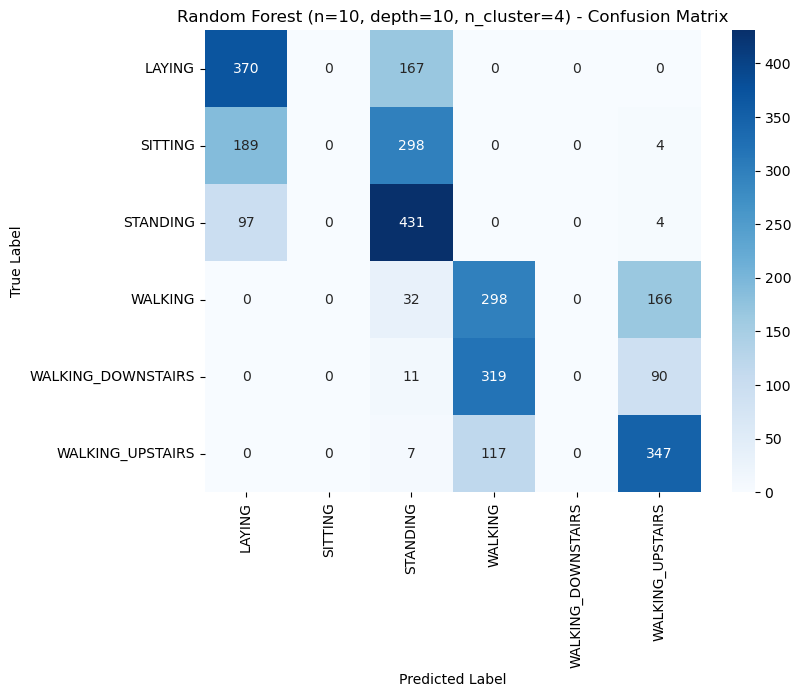

d:\MiniMiniConda\envs\MSE413\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\MiniMiniConda\envs\MSE413\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\MiniMiniConda\envs\MSE413\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\MiniMiniConda\envs\MSE413\lib\site-packages\sklearn\metrics\_classi

Accuracy: 0.4445
Sensitivity: 0.4269
Specificity: 0.8881
F1 Score: 0.3687

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.83      0.64       537
           1       0.28      0.22      0.25       491
           2       0.49      0.36      0.41       532
           3       0.39      0.90      0.55       496
           4       0.00      0.00      0.00       420
           5       0.65      0.25      0.36       471

    accuracy                           0.44      2947
   macro avg       0.39      0.43      0.37      2947
weighted avg       0.40      0.44      0.38      2947



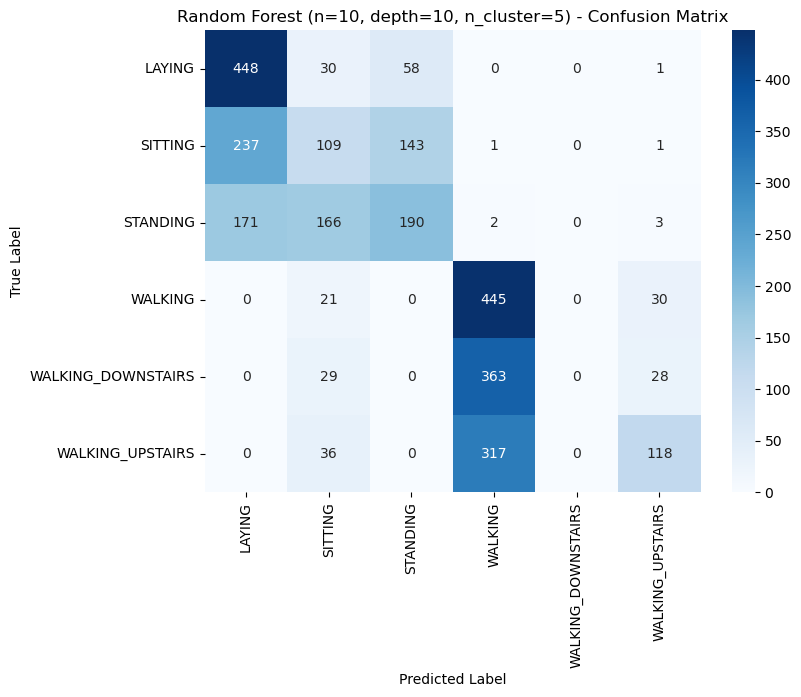

d:\MiniMiniConda\envs\MSE413\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Accuracy: 0.3655
Sensitivity: 0.3599
Specificity: 0.8729
F1 Score: 0.3513

Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.75      0.58       537
           1       0.16      0.23      0.18       491
           2       0.46      0.27      0.34       532
           3       0.30      0.15      0.20       496
           4       0.32      0.29      0.30       420
           5       0.54      0.46      0.50       471

    accuracy                           0.37      2947
   macro avg       0.37      0.36      0.35      2947
weighted avg       0.38      0.37      0.35      2947



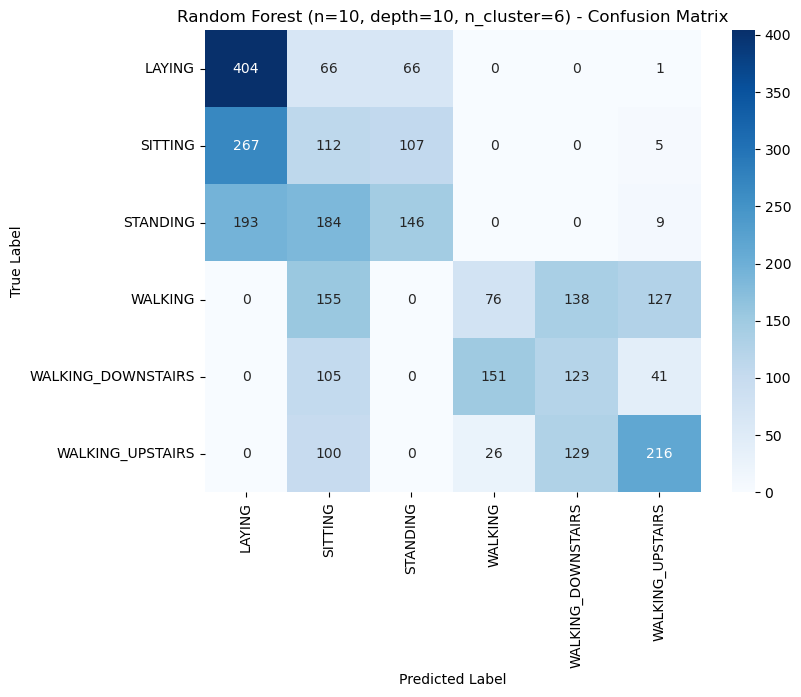

+----------+---------------------+---------------------+--------------------+---------------------+
| Clusters |      Accuracy       |     Sensitivity     |    Specificity     |      F1 Score       |
+----------+---------------------+---------------------+--------------------+---------------------+
|    3     | 0.4292500848320326  | 0.40639498311014516 | 0.8847835378807654 | 0.2829179886971171  |
|    4     | 0.4906684764166949  |  0.472783370644781  | 0.8972611866490703 | 0.3882438692646502  |
|    5     | 0.44451985069562266 |  0.426851903461728  | 0.8880914496619076 | 0.3686792225328968  |
|    6     | 0.3654563963352562  | 0.3599252364506283  | 0.8728896411005304 | 0.35128590591640446 |
+----------+---------------------+---------------------+--------------------+---------------------+


In [9]:
# Tabulate results for different cluster counts
cluster_test = range(3, 7)  # From 3 to 6, because there are 6 unique targets
results = []
for k in cluster_test:
    rf_model, accuracy, sensitivity, specificity, f1 = semi_supervised_auto_labeling(
        n_clusters=k,
        features_scaled=features_scaled,
        target=target,
        features_test_scaled=features_test_scaled,
        target_test_encoded=target_test_encoded,
        label_encoder=label_encoder
    )
    results.append([k, accuracy, sensitivity, specificity, f1])

print(tabulate.tabulate(results, headers=["Clusters", "Accuracy", "Sensitivity", "Specificity", "F1 Score"], tablefmt="pretty"))

### Compare the best performance obtained in section 7 and the performance of section 3. Do you see any improvement and why?

For comparision between 10 estimators with depth of 10 and 20 estimators with depth of 20, the accuracy is improve in the later model, and the other metrics in the same cluster of 6 are relative similar. The best in this iteration is one with 4 clusters with highest accuracy, sensitivity, specificity, and F1 score. Overall, the dataset is imblance, which leads to a poor model with extremely high specificity but low on others. 4 clusters labeling is the best it can do. This model can differentiate between laying, station (standing and sitting), walking upstair, and other walking (walking and walking downstairs).

More labeled samples before putting into K-mean model would be helpful. In this case, the specificity is especially high while other metrics are poor.

- The dataset is imbalance, proven by f1 score. The error source is the mislabel in the K-means model
- The model can only identify negative cases (high specificity). It struggles to generalize and correctly classify actual positive cases.
- Due to nature of the dataset has overlap data, which is difficult to classify different classes. Since there are 6 different unique activities, the best possible number of cluster is 6, but can be more generalize into 3, because sitting and standing are stationary, and walking, walking upstairs, and walking downstairs are moving in general.

Possible solutions to solve the imbalance dataset

- Tune the number of estimators and depth of random forest model
- Use different clustering methods, besides K-mean
- Use other methods for semi-supervised
- Add a model or strategies to handle the imbalance dataset
- Re-label the dataset to 3 activities only to improve the model's ability to generalize the information